# Gap-fill meteo variables

</br>

# Settings

## Data settings

In [11]:
SITE_LAT = 47.478333   # CH-LAE
SITE_LON = 8.364389  # CH-LAE
TIMEZONE_OFFSET_TO_UTC_HOURS = 1  # Timezone, e.g. "1" is translated to timezone "UTC+01:00" (CET, winter time)

## Imports

In [12]:
from datetime import datetime
import importlib.metadata
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
sns.set_theme('notebook')
import diive as dv
from diive.core.plotting.timeseries import TimeSeries
from diive.core.io.files import load_parquet, save_parquet
from diive.core.plotting.heatmap_datetime import HeatmapDateTime
from diive.core.times.times import DetectFrequency
from diive.core.times.times import TimestampSanitizer
from diive.pkgs.createvar.potentialradiation import potrad
from diive.pkgs.corrections.offsetcorrection import remove_relativehumidity_offset, remove_radiation_zero_offset
from diive.pkgs.gapfilling.longterm import LongTermGapFillingXGBoostTS
import warnings
from influxdb_client.client.warnings import MissingPivotFunction
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings(action='ignore', category=UserWarning)
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
version_diive = importlib.metadata.version("diive")
print(f"diive version: v{version_diive}")

diive version: v0.90.0


</br>

# Load data from files

In [13]:
filename_meteo6_2004_2025 = "02_METEO6_NOT-GAPFILLED_2004-2025.parquet"
meteo6_2004_2025 = load_parquet(filepath=filename_meteo6_2004_2025)
meteo6_2004_2025

Loaded .parquet file 02_METEO6_NOT-GAPFILLED_2004-2025.parquet (0.018 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1
TIMESTAMP_MIDDLE,,,,,,
2004-01-01 00:15:00,96.366667,0.0,-2.666667,NaN,NaN,NaN
2004-01-01 00:45:00,95.566667,0.0,-2.566667,NaN,NaN,NaN
2004-01-01 01:15:00,92.200000,0.0,-2.533333,NaN,NaN,NaN
2004-01-01 01:45:00,91.300000,0.0,-2.633333,NaN,NaN,NaN
2004-01-01 02:15:00,92.633333,0.0,-2.800000,NaN,NaN,NaN
...,...,...,...,...,...,...
2025-12-31 21:45:00,42.332976,0.0,-3.081644,210.420480,0.0,93.435334
2025-12-31 22:15:00,39.230344,0.0,-3.084372,210.648200,0.0,93.422110
2025-12-31 22:45:00,55.771803,0.0,-3.423939,211.147057,0.0,93.404179


In [14]:
# meteo6_2004_2025 = meteo6_2004_2025.loc[meteo6_2004_2025.index.year > 2020].copy()

In [15]:
meteo6_2004_2025.describe()

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1
count,384175.000000,385124.000000,384264.000000,352171.000000,371801.000000,353407.000000
mean,78.080751,142.734231,9.387278,310.622397,288.553170,93.231461
std,18.478266,237.273570,8.020959,45.554221,486.442862,0.738367
min,13.666667,0.000000,-16.366667,135.445129,0.000000,89.446007
25%,64.733333,0.000000,3.139529,282.514256,0.000000,92.849526
50%,81.600000,0.000000,9.385775,315.875107,0.000000,93.306000
75%,94.733333,191.378154,15.366667,343.460725,370.483220,93.696730
max,100.000000,1236.201961,33.558765,441.779694,2270.612673,95.543335


In [46]:
meteo6_2004_2025['TA_T1_47_1'].isnull().sum()

np.int64(1464)

</br>

# Gap-filling

## SW_IN_T1_47_1

### Target and features

In [16]:
TARGET = "SW_IN_T1_47_1"
subset = pd.DataFrame()
subset[TARGET] = meteo6_2004_2025[[TARGET]].copy()
subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,SW_IN_T1_47_1,SW_IN_POT
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,0.0,0.0
2004-01-01 00:45:00,0.0,0.0
2004-01-01 01:15:00,0.0,0.0
2004-01-01 01:45:00,0.0,0.0
2004-01-01 02:15:00,0.0,0.0
...,...,...
2025-12-31 21:45:00,0.0,0.0
2025-12-31 22:15:00,0.0,0.0
2025-12-31 22:45:00,0.0,0.0


### Initialize gap-filling

In [17]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=3,
    n_estimators=9,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=100,
    max_depth=4,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 385728.


### Initialize yearly models

In [18]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2004, 2005, 2006] to data pool for 2004.
[neighboring_years] Assigned [2004, 2005, 2006] to data pool for 2005.
[neighboring_years] Assigned [2005, 2006, 2007] to data pool for 2006.
[neighboring_years] Assigned [2006, 2007, 2008] to data pool for 2007.
[neighboring_years] Assigned [2007, 2008, 2009] to data pool for 2008.
[neighboring_years] Assigned [2008, 2009, 2010] to data pool for 2009.
[neighboring_years] Assigned [2009, 2010, 2011] to data pool for 2010.
[neighboring_years] Assigned [2010, 2011, 2012] to data pool for 2011.
[neighboring_years] Assigned [2011, 2012, 2013] to data pool for 2012.
[neighboring_years] Assigned [2012, 2013, 2014] to data pool for 2013.
[neighboring_years] Assigned [2013, 2014, 2015] to data pool for 2014.
[neighboring_years] Assigned [2014, 2015, 2016] to data pool for 2015.
[neighboring_years] Assigned [2015, 2016, 2017] to data pool for 2016.
[neighboring_years] Assigned [2016, 2017, 2018] to data pool for 2017.
[neigh

### Reduce features across years

In [19]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2004 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:179.90364	validation_1-rmse:179.90364
[1]	validation_0-rmse:151.78177	validation_1-rmse:151.78177
[2]	validation_0-rmse:135.75365	validation_1-rmse:135.75365
[3]	validation_0-rmse:126.56363	validation_1-rmse:126.56363
[4]	validation_0-rmse:121.71773	validation_1-rmse:121.71773
[5]	validation_0-rmse:118.70938	validation_1-rmse:118.70938
[6]	validation_0-rmse:116.96379	validation_1-rmse:116.96379
[7]	validation_0-rmse:115.63765	validation_1-rmse:115.63765
[8]	validation_0-rmse:114.52673	validation_1-rmse:114.52673
[ FEATURE REDUCTION ] >>> Calculating feature importances (permutation importance, 3 repeats) ...
[ FEATURE REDUCTION ] >>> Setting threshold for feature rejection to 0.0.

[ FEATURE REDUCTION ] >>> Accepted features and their importance:
               PERM_IMPORTANCE
SW_IN_POT         1.346582e+00
.DOY_COS  

### Train models and fill gaps

In [20]:
ltxgb.fillgaps()


Training model for 2004 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2004-01-01 00:15:00 and 2006-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:179.90364	validation_1-rmse:182.24825
[1]	validation_0-rmse:151.78177	validation_1-rmse:153.55736
[2]	validation_0-rmse:135.75365	validation_1-rmse:137.38070
[3]	validation_0-rmse:126.56363	validation_1-rmse:128.14822
[4]	validation_0-rmse:121.71773	validation_1-rmse:123.28156
[5]	validation_0-rmse:118.70938	validation_1-rmse:120.27388
[6]	validation_0-rmse:116.96379	validation_1-rmse:118.56510
[7]	validation_0-rmse:115.63765	validation_1-rmse:117.25549
[8]	validation_0-rmse:114.52673	validation_1-rmse:116.12906
>>> Using model to predict target SW_IN_T1_47_1 in unseen test data ...
>>> Using model to calculate permutation importance based on unseen test data ...
>>> Calculating prediction scores based on predicting unseen test data of SW_IN_T1_4

### Results: yearly scores

In [21]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
mae,64.4927,64.4927,65.9158,66.9914,66.2446,64.7774,64.3346,65.2578,65.4510,66.1323,65.4893,66.5576,66.0101,64.3863,64.4094,65.6290,67.5268,66.8900,64.9450,63.3262,64.5222,64.5222
medae,6.2365,6.2365,6.1681,6.2040,6.7964,6.4260,6.6352,6.5224,6.4505,6.8146,6.9885,6.9116,7.2449,6.7000,6.6051,6.8179,6.9194,7.2461,6.9253,6.5103,6.4960,6.4960
mse,13208.7729,13208.7729,13678.8868,14086.7449,13970.9481,13471.2061,13274.5757,13532.1472,13618.0371,13837.0092,13575.2477,14026.9672,13695.7884,13231.4153,13026.7036,13427.1325,14181.6578,14002.7207,13168.7469,12593.6090,12940.2221,12940.2221
rmse,114.9294,114.9294,116.9568,118.6876,118.1988,116.0655,115.2153,116.3278,116.6963,117.6308,116.5129,118.4355,117.0290,115.0279,114.1346,115.8755,119.0868,118.3331,114.7552,112.2213,113.7551,113.7551
mape,12751756302812378.0000,12751756302812378.0000,12960597612961804.0000,12949411895770970.0000,13142065972554120.0000,12970800885338088.0000,13497461027447452.0000,13374007317800462.0000,13438252449629378.0000,13053658351838470.0000,13394717187631756.0000,13476284201648992.0000,13602390418952378.0000,13674708427140228.0000,14205592153898796.0000,14582765341106670.0000,14724466856635776.0000,14602312933687054.0000,14413199445331060.0000,13895762215719354.0000,13584746245927984.0000,13584746245927984.0000
maxe,653.2643,653.2643,650.2981,623.1786,666.7900,632.2146,657.2042,629.0580,722.1250,649.4873,618.7757,627.7052,607.5817,652.0893,662.7866,691.2805,677.4253,684.5373,762.9813,686.5244,671.5205,671.5205
r2,0.7436,0.7436,0.7384,0.7314,0.7412,0.7437,0.7581,0.7530,0.7539,0.7424,0.7531,0.7472,0.7603,0.7706,0.7845,0.7846,0.7698,0.7766,0.7829,0.7840,0.7699,0.7699


### Results: feature importances

In [22]:
ltxgb.feature_importances_yearly_

{'2004':                PERM_IMPORTANCE       PERM_SD
 SW_IN_POT         1.353385e+00  5.884995e-03
 .DOY_COS          2.177469e-02  5.783702e-04
 .DOY_SIN          1.628039e-02  4.464171e-04
 .RECORDNUMBER     1.080543e-02  2.094489e-04
 .YEARDOY          5.675010e-03  3.609892e-04
 .YEARWEEK         2.489412e-03  2.279132e-04
 .WEEK_COS         7.192162e-04  4.119906e-05
 .YEARMONTH        6.731097e-04  5.031279e-05
 .WEEK_SIN         4.903191e-04  5.652056e-05
 .HOUR_COS         1.225850e-04  1.673980e-06
 .MONTH_COS        1.005363e-04  1.047831e-06
 .HOUR_SIN         7.465265e-07  7.113310e-08
 .SEASON_COS       0.000000e+00  0.000000e+00
 .MONTH_SIN        0.000000e+00  0.000000e+00
 .YEAR             0.000000e+00  0.000000e+00
 .SEASON_SIN       0.000000e+00  0.000000e+00,
 '2005':                PERM_IMPORTANCE       PERM_SD
 SW_IN_POT         1.353385e+00  5.884995e-03
 .DOY_COS          2.177469e-02  5.783702e-04
 .DOY_SIN          1.628039e-02  4.464171e-04
 .RECORDNUMBER   

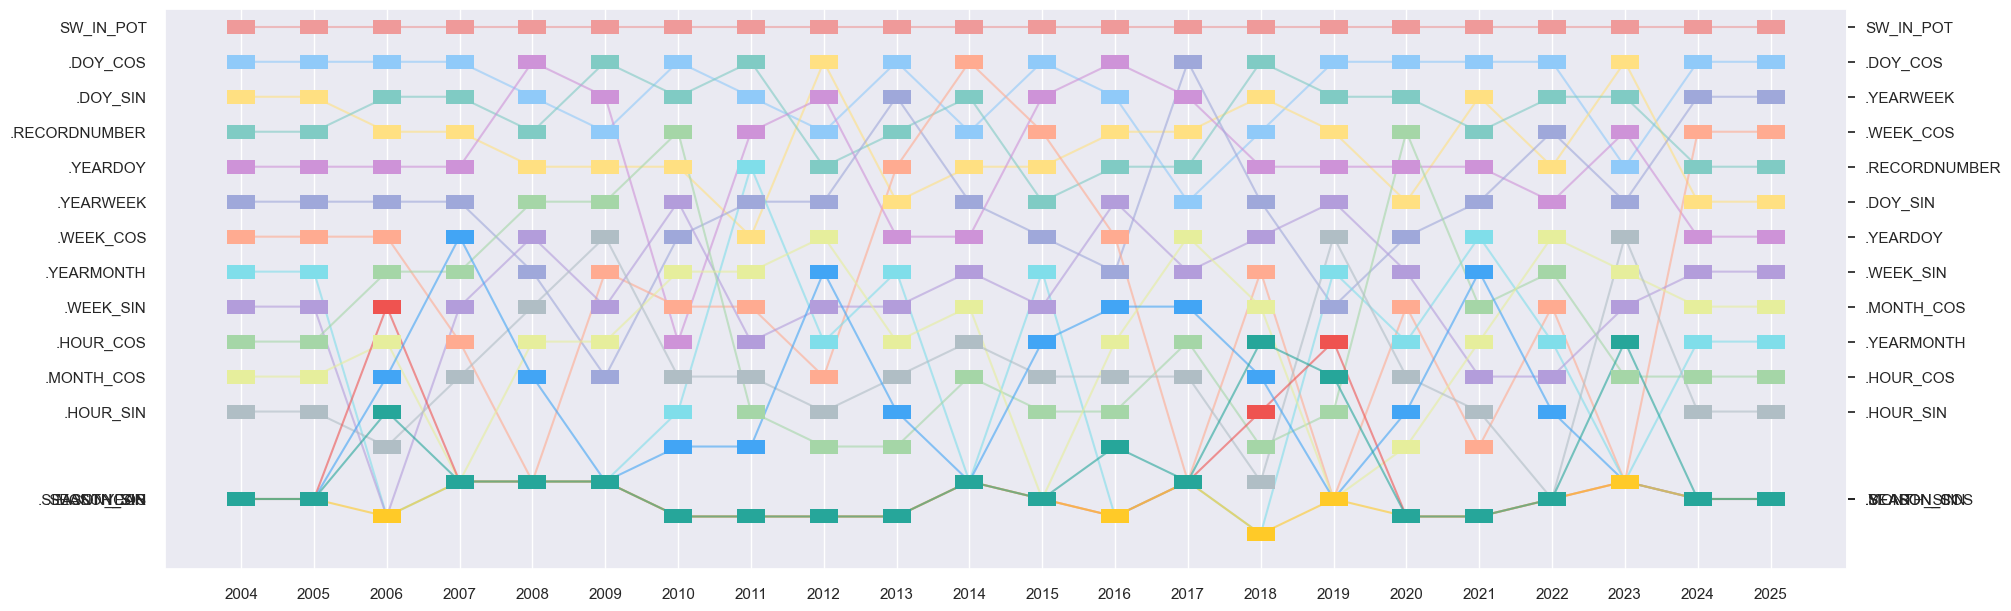

In [23]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

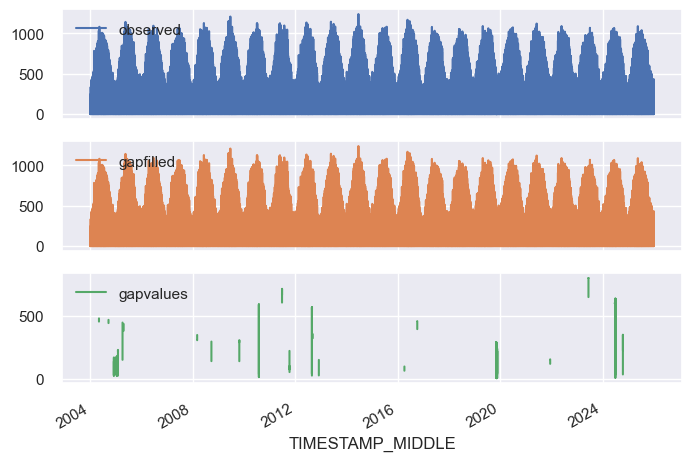

In [24]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [25]:
meteo6_2004_2025[gapfilled.name] = gapfilled

### Plot time series

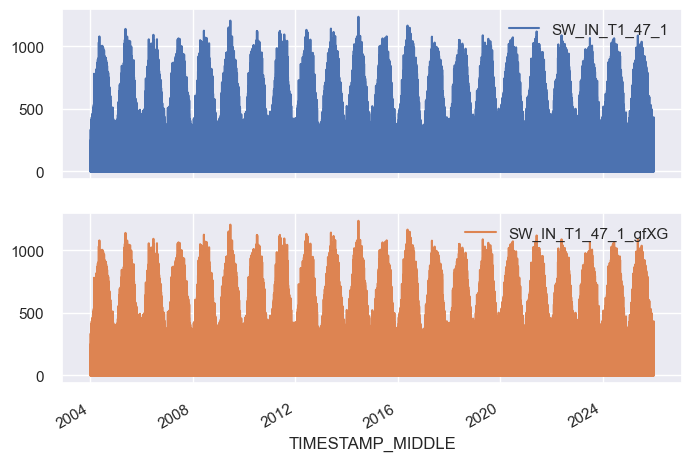

In [26]:
meteo6_2004_2025[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Correction: Remove zero offset < 0 from `SW_IN_T1_47_1_gfXG`
- Additional correction needed because gap-filling introduced values < 0

In [27]:
meteo6_2004_2025[[TARGET, gapfilled.name]].describe()

,SW_IN_T1_47_1,SW_IN_T1_47_1_gfXG
count,385124.000000,385728.000000
mean,142.734231,142.872987
std,237.273570,237.218245
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,191.378154,191.944217
max,1236.201961,1236.201961


[remove_radiation_zero_offset]  running remove_radiation_zero_offset ...


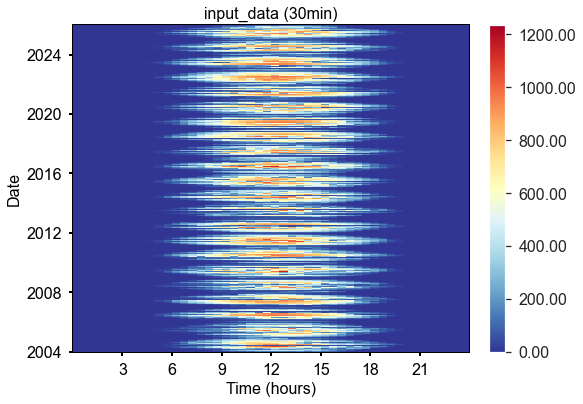

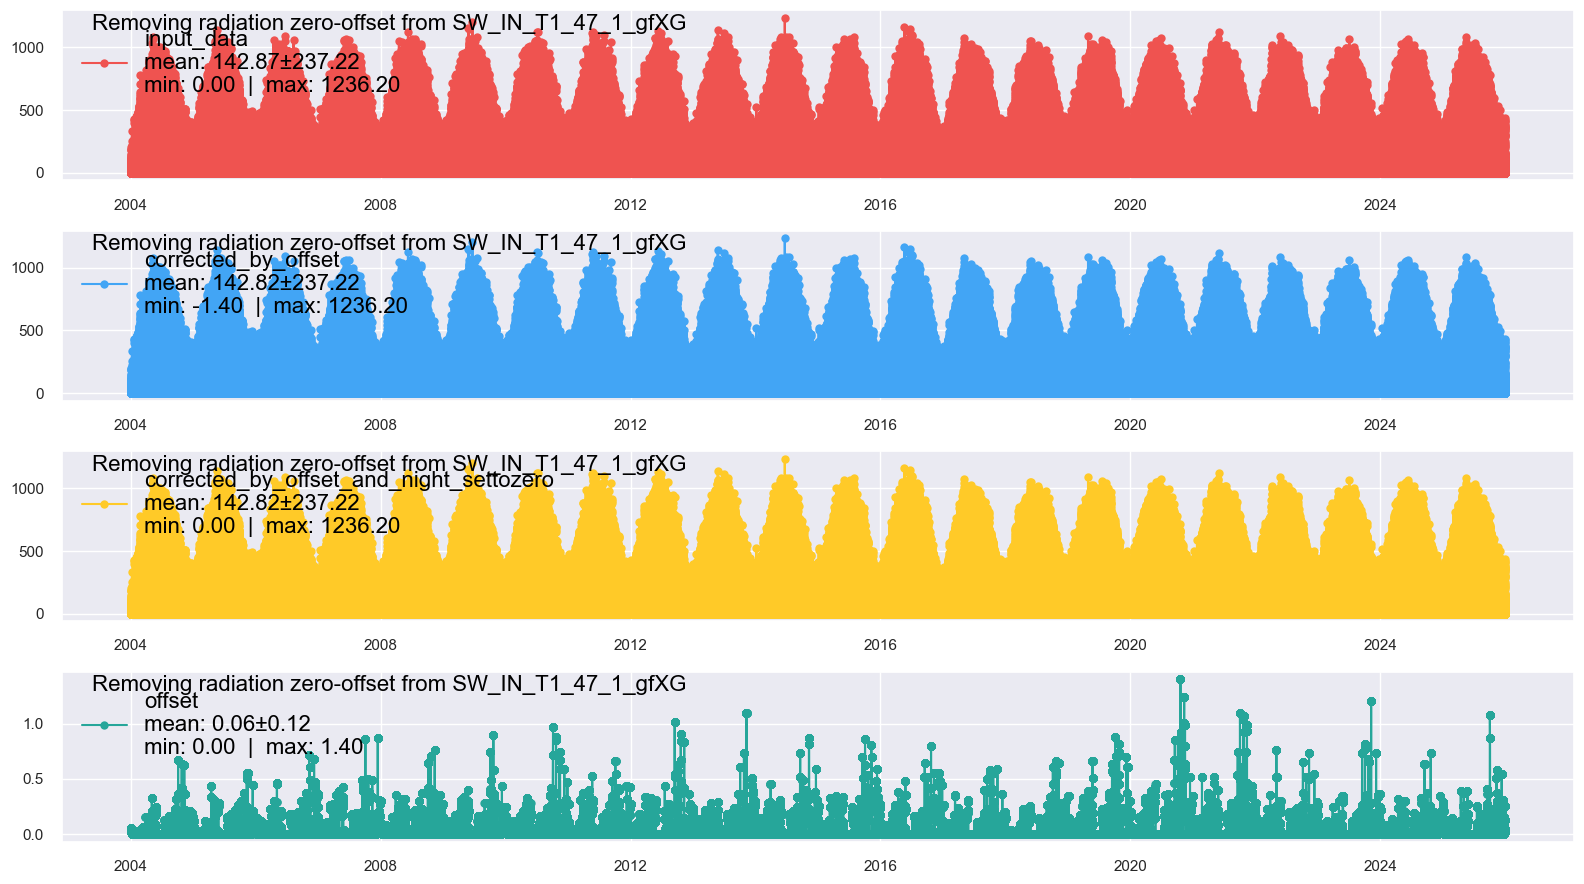

In [28]:
_swin = meteo6_2004_2025['SW_IN_T1_47_1_gfXG'].copy()
_swin_corrected = remove_radiation_zero_offset(series=_swin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
meteo6_2004_2025['SW_IN_T1_47_1_gfXG'] = np.nan
meteo6_2004_2025['SW_IN_T1_47_1_gfXG'] = _swin_corrected

### Final dataframe

In [29]:
meteo6_2004_2025

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,
2004-01-01 00:15:00,96.366667,0.0,-2.666667,NaN,NaN,NaN,0.0
2004-01-01 00:45:00,95.566667,0.0,-2.566667,NaN,NaN,NaN,0.0
2004-01-01 01:15:00,92.200000,0.0,-2.533333,NaN,NaN,NaN,0.0
2004-01-01 01:45:00,91.300000,0.0,-2.633333,NaN,NaN,NaN,0.0
2004-01-01 02:15:00,92.633333,0.0,-2.800000,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...
2025-12-31 21:45:00,42.332976,0.0,-3.081644,210.420480,0.0,93.435334,0.0
2025-12-31 22:15:00,39.230344,0.0,-3.084372,210.648200,0.0,93.422110,0.0
2025-12-31 22:45:00,55.771803,0.0,-3.423939,211.147057,0.0,93.404179,0.0


In [30]:
meteo6_2004_2025.describe()

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1,SW_IN_T1_47_1_gfXG
count,384175.000000,385124.000000,384264.000000,352171.000000,371801.000000,353407.000000,385728.000000
mean,78.080751,142.734231,9.387278,310.622397,288.553170,93.231461,142.816715
std,18.478266,237.273570,8.020959,45.554221,486.442862,0.738367,237.216812
min,13.666667,0.000000,-16.366667,135.445129,0.000000,89.446007,0.000000
25%,64.733333,0.000000,3.139529,282.514256,0.000000,92.849526,0.000000
50%,81.600000,0.000000,9.385775,315.875107,0.000000,93.306000,0.000000
75%,94.733333,191.378154,15.366667,343.460725,370.483220,93.696730,191.885169
max,100.000000,1236.201961,33.558765,441.779694,2270.612673,95.543335,1236.201961


</br>

</br>

</br>

## TA_T1_47_1

### Target and features

In [31]:
TARGET = "TA_T1_47_1"
subset = pd.DataFrame()
subset[TARGET] = meteo6_2004_2025[[TARGET]].copy()
subset['SW_IN_T1_47_1_gfXG'] = meteo6_2004_2025['SW_IN_T1_47_1_gfXG'].copy()
# subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

,TA_T1_47_1,SW_IN_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,
2004-01-01 00:15:00,-2.666667,0.0
2004-01-01 00:45:00,-2.566667,0.0
2004-01-01 01:15:00,-2.533333,0.0
2004-01-01 01:45:00,-2.633333,0.0
2004-01-01 02:15:00,-2.800000,0.0
...,...,...
2025-12-31 21:45:00,-3.081644,0.0
2025-12-31 22:15:00,-3.084372,0.0
2025-12-31 22:45:00,-3.423939,0.0


### Initialize gap-filling

In [32]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=3,
    n_estimators=9,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=4,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)


Adding new data columns ...
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 385728.


### Initialize yearly models

In [33]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

[neighboring_years] Assigned [2004, 2005, 2006] to data pool for 2004.
[neighboring_years] Assigned [2004, 2005, 2006] to data pool for 2005.
[neighboring_years] Assigned [2005, 2006, 2007] to data pool for 2006.
[neighboring_years] Assigned [2006, 2007, 2008] to data pool for 2007.
[neighboring_years] Assigned [2007, 2008, 2009] to data pool for 2008.
[neighboring_years] Assigned [2008, 2009, 2010] to data pool for 2009.
[neighboring_years] Assigned [2009, 2010, 2011] to data pool for 2010.
[neighboring_years] Assigned [2010, 2011, 2012] to data pool for 2011.
[neighboring_years] Assigned [2011, 2012, 2013] to data pool for 2012.
[neighboring_years] Assigned [2012, 2013, 2014] to data pool for 2013.
[neighboring_years] Assigned [2013, 2014, 2015] to data pool for 2014.
[neighboring_years] Assigned [2014, 2015, 2016] to data pool for 2015.
[neighboring_years] Assigned [2015, 2016, 2017] to data pool for 2016.
[neighboring_years] Assigned [2016, 2017, 2018] to data pool for 2017.
[neigh

### Reduce features across years

In [34]:
ltxgb.reduce_features_across_years()

---
Reducing features based on permutation importance for year 2004 ...

[ FEATURE REDUCTION ] Feature reduction based on permutation importance ...
[0]	validation_0-rmse:6.49493	validation_1-rmse:6.49493
[1]	validation_0-rmse:5.30092	validation_1-rmse:5.30092
[2]	validation_0-rmse:4.55168	validation_1-rmse:4.55168
[3]	validation_0-rmse:4.08861	validation_1-rmse:4.08861
[4]	validation_0-rmse:3.79783	validation_1-rmse:3.79783
[5]	validation_0-rmse:3.62312	validation_1-rmse:3.62312
[6]	validation_0-rmse:3.48180	validation_1-rmse:3.48180
[7]	validation_0-rmse:3.37431	validation_1-rmse:3.37431
[8]	validation_0-rmse:3.31177	validation_1-rmse:3.31177
[ FEATURE REDUCTION ] >>> Calculating feature importances (permutation importance, 3 repeats) ...
[ FEATURE REDUCTION ] >>> Setting threshold for feature rejection to 0.0.

[ FEATURE REDUCTION ] >>> Accepted features and their importance:
                    PERM_IMPORTANCE
.WEEK_COS                  0.368173
.DOY_COS                   0.262990


### Train models and fill gaps

In [35]:
ltxgb.fillgaps()


Training model for 2004 ...

Training final model ...
>>> Training model <class 'xgboost.sklearn.XGBRegressor'> based on data between 2004-01-01 00:15:00 and 2006-12-31 23:45:00 ...
>>> Fitting model to training data ...
[0]	validation_0-rmse:6.49493	validation_1-rmse:6.49434
[1]	validation_0-rmse:5.30092	validation_1-rmse:5.30536
[2]	validation_0-rmse:4.55168	validation_1-rmse:4.55359
[3]	validation_0-rmse:4.08861	validation_1-rmse:4.09043
[4]	validation_0-rmse:3.79783	validation_1-rmse:3.80135
[5]	validation_0-rmse:3.62312	validation_1-rmse:3.63061
[6]	validation_0-rmse:3.48180	validation_1-rmse:3.48690
[7]	validation_0-rmse:3.37431	validation_1-rmse:3.38206
[8]	validation_0-rmse:3.31177	validation_1-rmse:3.32034
>>> Using model to predict target TA_T1_47_1 in unseen test data ...
>>> Using model to calculate permutation importance based on unseen test data ...
>>> Calculating prediction scores based on predicting unseen test data of TA_T1_47_1 ...
>>> Collecting results, details ab

### Results: yearly scores

In [36]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
mae,2.6292,2.6292,2.7543,2.6532,2.6193,2.7046,2.7759,2.7941,2.8041,2.5858,2.5456,2.6090,2.7599,2.7479,2.7693,2.7482,2.7479,2.6840,2.5524,2.5600,2.7717,2.7717
medae,2.1992,2.1992,2.3677,2.3064,2.2707,2.3733,2.4283,2.4023,2.3696,2.1178,2.1032,2.2411,2.4002,2.3482,2.4098,2.3550,2.3718,2.2878,2.1373,2.1361,2.3953,2.3953
mse,10.9820,10.9820,11.7414,10.7334,10.5194,11.0607,11.6250,12.0194,12.3307,10.8619,10.3435,10.6560,11.5401,11.4683,11.8497,11.6041,11.6958,11.2738,10.2861,10.3200,11.8675,11.8675
rmse,3.3139,3.3139,3.4266,3.2762,3.2434,3.3258,3.4096,3.4669,3.5115,3.2957,3.2161,3.2644,3.3971,3.3865,3.4423,3.4065,3.4199,3.3576,3.2072,3.2125,3.4449,3.4449
mape,10390061844856.9102,10390061844856.9102,10896436169398.0410,11572813132119.2051,9539977087880.7520,9598749052094.3105,8197871334653.9561,7313170734479.2246,8813191913636.7051,8770574459000.5732,12895572078618.3438,14214340608889.6426,13937399958086.7383,9552051836258.3008,4194683407696.1172,507943342949.6932,3.7273,3.4892,3.1293,3.6517,3.2730,3.2730
maxe,19.2289,19.2289,11.8488,12.5437,12.3439,13.8298,13.0289,12.4943,12.5811,12.8705,12.9697,13.2349,11.6405,13.0636,13.6110,12.2551,12.4789,12.4609,13.4066,12.0444,12.4973,12.4973
r2,0.8412,0.8412,0.8242,0.8216,0.8201,0.8288,0.8237,0.8187,0.8118,0.8227,0.8256,0.8053,0.8198,0.8323,0.8324,0.8241,0.8090,0.8182,0.8421,0.8397,0.8111,0.8111


### Results: feature importances

In [37]:
ltxgb.feature_importances_yearly_

{'2004':                     PERM_IMPORTANCE   PERM_SD
 .DOY_COS                   0.417731  0.001614
 .WEEK_COS                  0.264739  0.001894
 .WEEK_SIN                  0.133991  0.000606
 .DOY_SIN                   0.054905  0.000507
 .YEARWEEK                  0.033762  0.000617
 .HOUR_SIN                  0.032774  0.000543
 SW_IN_T1_47_1_gfXG         0.028729  0.000580
 .RECORDNUMBER              0.019456  0.000151
 .YEARDOY                   0.013750  0.000180
 .MONTH_SIN                 0.002208  0.000100
 .MONTH_COS                 0.000161  0.000064
 .HOUR_COS                  0.000000  0.000000
 .SEASON_COS                0.000000  0.000000
 .SEASON_SIN                0.000000  0.000000
 .YEAR                      0.000000  0.000000
 .YEARMONTH                 0.000000  0.000000,
 '2005':                     PERM_IMPORTANCE   PERM_SD
 .DOY_COS                   0.417731  0.001614
 .WEEK_COS                  0.264739  0.001894
 .WEEK_SIN                  0.133991  0.000

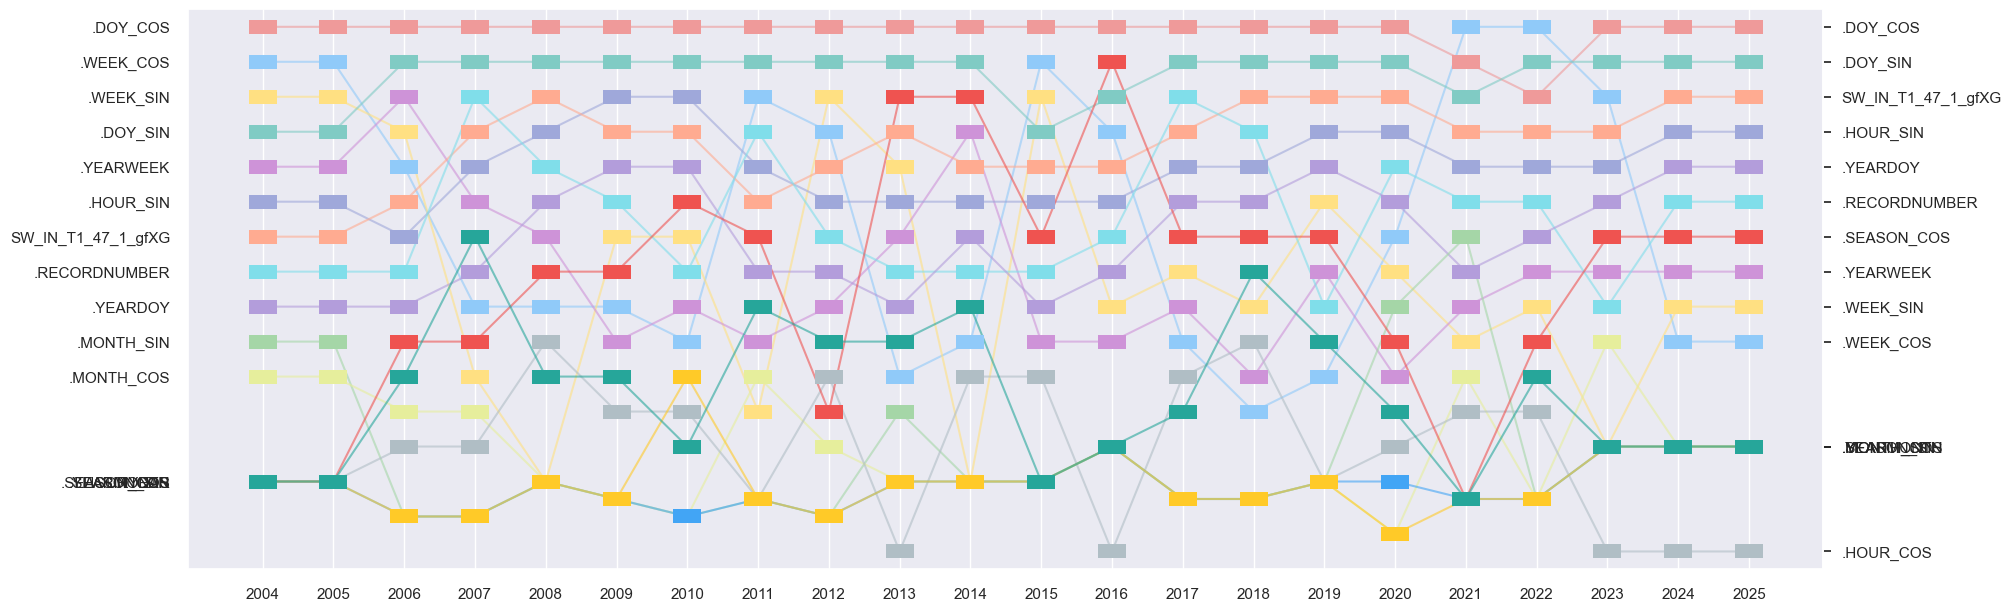

In [38]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

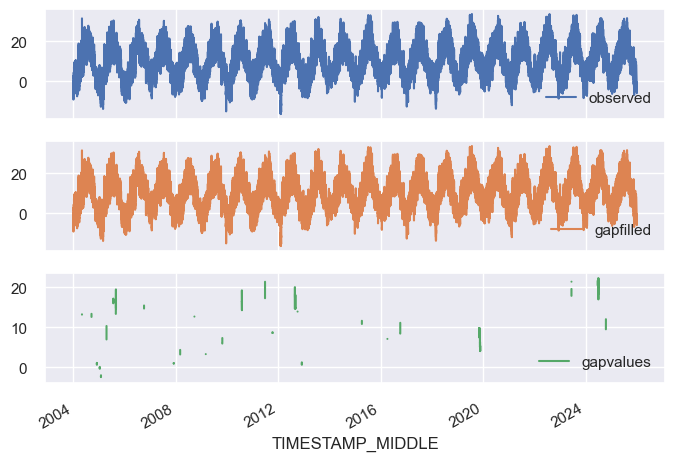

In [39]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [40]:
meteo6_2004_2025[gapfilled.name] = gapfilled

### Plot time series

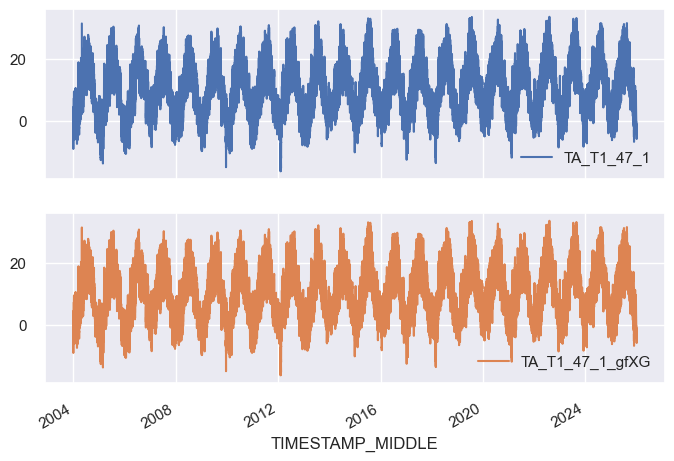

In [41]:
meteo6_2004_2025[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Final dataframe

In [42]:
meteo6_2004_2025

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1,SW_IN_T1_47_1_gfXG,TA_T1_47_1_gfXG
TIMESTAMP_MIDDLE,,,,,,,,
2004-01-01 00:15:00,96.366667,0.0,-2.666667,NaN,NaN,NaN,0.0,-2.666667
2004-01-01 00:45:00,95.566667,0.0,-2.566667,NaN,NaN,NaN,0.0,-2.566667
2004-01-01 01:15:00,92.200000,0.0,-2.533333,NaN,NaN,NaN,0.0,-2.533333
2004-01-01 01:45:00,91.300000,0.0,-2.633333,NaN,NaN,NaN,0.0,-2.633333
2004-01-01 02:15:00,92.633333,0.0,-2.800000,NaN,NaN,NaN,0.0,-2.800000
...,...,...,...,...,...,...,...,...
2025-12-31 21:45:00,42.332976,0.0,-3.081644,210.420480,0.0,93.435334,0.0,-3.081644
2025-12-31 22:15:00,39.230344,0.0,-3.084372,210.648200,0.0,93.422110,0.0,-3.084372
2025-12-31 22:45:00,55.771803,0.0,-3.423939,211.147057,0.0,93.404179,0.0,-3.423939


In [43]:
meteo6_2004_2025.describe()

,RH_T1_47_1,SW_IN_T1_47_1,TA_T1_47_1,LW_IN_T1_47_1,PPFD_IN_T1_47_1,PA_T1_47_1,SW_IN_T1_47_1_gfXG,TA_T1_47_1_gfXG
count,384175.000000,385124.000000,384264.000000,352171.000000,371801.000000,353407.000000,385728.000000,385728.000000
mean,78.080751,142.734231,9.387278,310.622397,288.553170,93.231461,142.816715,9.385553
std,18.478266,237.273570,8.020959,45.554221,486.442862,0.738367,237.216812,8.013698
min,13.666667,0.000000,-16.366667,135.445129,0.000000,89.446007,0.000000,-16.366667
25%,64.733333,0.000000,3.139529,282.514256,0.000000,92.849526,0.000000,3.166667
50%,81.600000,0.000000,9.385775,315.875107,0.000000,93.306000,0.000000,9.366667
75%,94.733333,191.378154,15.366667,343.460725,370.483220,93.696730,191.885169,15.366667
max,100.000000,1236.201961,33.558765,441.779694,2270.612673,95.543335,1236.201961,33.558765


</br>

In [48]:
meteo6_2004_2025['TA_T1_47_1_gfXG'].groupby(meteo6_2004_2025.index.year).mean()

TIMESTAMP_MIDDLE
2004     8.213181
2005     8.197418
2006     8.875180
2007     9.080893
2008     8.617632
2009     8.931121
2010     7.706985
2011     9.620383
2012     8.703531
2013     8.065160
2014     9.912230
2015     9.723377
2016     8.951022
2017     9.138560
2018    10.387717
2019    10.359333
2020    10.504883
2021     9.056597
2022    11.120893
2023    10.765296
2024    10.331355
2025    10.222141
Name: TA_T1_47_1_gfXG, dtype: float64

</br>

</br>

## PPFD_IN_T1_47_1

### Target and features

In [ ]:
TARGET = "PPFD_IN_T1_47_1"
subset = pd.DataFrame()
subset[TARGET] = meteo6_2004_2025[[TARGET]].copy()
subset['SW_IN_T1_47_1_gfXG'] = meteo6_2004_2025['SW_IN_T1_47_1_gfXG'].copy()
# subset['SW_IN_POT'] = potrad(timestamp_index=subset.index, lat=SITE_LAT, lon=SITE_LON, utc_offset=1)
subset

### Initialize gap-filling

In [ ]:
ltxgb = LongTermGapFillingXGBoostTS(
    input_df=subset,
    target_col=TARGET,
    verbose=0,
    # features_lag=[-1, -1],
    vectorize_timestamps=True,
    add_continuous_record_number=True,
    sanitize_timestamp=True,
    perm_n_repeats=9,
    n_estimators=1000,
    random_state=42,
    # booster='gbtree',  # gbtree (default), gblinear, dart
    # device='cpu',
    validate_parameters=True,
    # disable_default_eval_metric=False,
    early_stopping_rounds=50,
    max_depth=6,
    # max_delta_step=0,
    # subsample=1,
    learning_rate=0.3,
    # min_split_loss=0,
    # min_child_weight=1,
    # colsample_bytree=1,
    # colsample_bylevel=1,
    # colsample_bynode=1,
    # reg_lambda=1,
    # reg_alpha=0,
    tree_method='auto',  # auto, hist, approx, exact
    # scale_pos_weight=1,
    # grow_policy=0,
    grow_policy='lossguide',  # depthwise, lossguide
    # max_leaves=0,
    # max_bin=256,
    # num_parallel_tree=1,
    n_jobs=-1
)

### Initialize yearly models

In [ ]:
ltxgb.create_yearpools()
ltxgb.initialize_yearly_models()

### Reduce features across years

In [ ]:
ltxgb.reduce_features_across_years()

### Train models and fill gaps

In [ ]:
ltxgb.fillgaps()

### Results: yearly scores

In [ ]:
scores = pd.DataFrame(ltxgb.scores_)
scores.style.format("{:.4f}")

### Results: feature importances

In [ ]:
ltxgb.feature_importances_yearly_

In [ ]:
ltxgb.showplot_feature_ranks_per_year()

### Results: plot gap-filled time series

In [ ]:
observed = subset[TARGET]
gapfilled = ltxgb.gapfilled_
locs_filled = observed.isna()
gapvalues = gapfilled[locs_filled].copy()
# gapfilled[locs_filled].describe()
_plotdf = pd.DataFrame({
    'observed': observed,
    'gapfilled': gapfilled,
    'gapvalues': gapvalues
})
_plotdf.plot(subplots=True, x_compat=True);

### Add gap-filled series to dataframe

In [ ]:
meteo6_2004_2025[gapfilled.name] = gapfilled

### Plot time series

In [ ]:
meteo6_2004_2025[[TARGET, gapfilled.name]].plot(subplots=True, x_compat=True);

### Correction: Remove zero offset < 0 from `PPFD_IN_T1_47_1_gfXG`
- Additional correction needed because gap-filling introduced values < 0

In [ ]:
meteo6_2004_2025[[TARGET, gapfilled.name]].describe()

In [ ]:
_ppfdin = meteo6_2004_2025['PPFD_IN_T1_47_1_gfXG'].copy()
_ppfdin_corrected = remove_radiation_zero_offset(series=_ppfdin, lat=SITE_LAT, lon=SITE_LON, utc_offset=1, showplot=True)
meteo6_2004_2025['PPFD_IN_T1_47_1_gfXG'] = np.nan
meteo6_2004_2025['PPFD_IN_T1_47_1_gfXG'] = _ppfdin_corrected

### Final dataframe

In [ ]:
meteo6_2004_2025

In [ ]:
meteo6_2004_2025.describe()

</br>

</br>

</br>

</br>

# Plot time series

In [ ]:
_plot_df = meteo6_2004_2025.copy()
_plot_df = _plot_df.replace(-9999, np.nan)
_plot_df.plot(subplots=True, figsize=(20, 9), title="Gap-filled (some) meteo data", alpha=.9, x_compat=True);

# Plot heatmaps

In [ ]:
meteo6_2004_2025

In [ ]:
fig, axs = plt.subplots(ncols=5, figsize=(24, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=meteo6_2004_2025['PPFD_IN_T1_47_1'], title="PPFD_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['PPFD_IN_T1_47_1_gfXG'], title="PPFD_IN_T1_47_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['RH_T1_47_1'], title="RH_T1_47_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['LW_IN_T1_47_1'], title="LW_IN_T1_47_1", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['PA_T1_47_1'], title="PA_T1_47_1", ax=axs[4], cb_digits_after_comma=0, zlabel="value").plot()

In [ ]:
fig, axs = plt.subplots(ncols=4, figsize=(18, 10), dpi=100, layout="constrained")
fig.suptitle(f'Half-hourly', fontsize=16)
dv.heatmapdatetime(series=meteo6_2004_2025['SW_IN_T1_47_1'], title="SW_IN_T1_47_1", ax=axs[0], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['SW_IN_T1_47_1_gfXG'], title="SW_IN_T1_47_1_gfXG", ax=axs[1], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['TA_T1_47_1'], title="TA_T1_47_1", ax=axs[2], cb_digits_after_comma=0, zlabel="value").plot()
dv.heatmapdatetime(series=meteo6_2004_2025['TA_T1_47_1_gfXG'], title="TA_T1_47_1_gfXG", ax=axs[3], cb_digits_after_comma=0, zlabel="value").plot()

</br>

# Stats

In [ ]:
meteo6_2004_2025.describe()

</br>

# Save to file

In [ ]:
OUTNAME = "12_METEO6_GAPFILLED_2004-2025"
OUTPATH = r""
filepath = save_parquet(filename=OUTNAME, data=meteo6_2004_2025, outpath=OUTPATH)
meteo6_2004_2025.to_csv(Path(OUTPATH) / f"{OUTNAME}.csv")

</br>

# End of notebook.

In [ ]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

</br>